# ASVspoof5 Train/Dev 16-System Dataset Description

This notebook describes the ASVspoof5 protocol files for a planned `16` binary logistic-regression setup:
- `bonafide vs A01` ... `bonafide vs A08` from `train`
- `bonafide vs A09` ... `bonafide vs A16` from `dev`

This notebook does **not** sample or train. Its role is to answer planning questions for the later notebooks:
- how many speakers exist
- how many utterances exist per system
- whether speakers overlap across partitions
- whether same-sentence matching is feasible from these protocol files
- what subset sizes are realistic for the later preparation notebook


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')


In [2]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
PROTOCOL_DIR = PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_protocols'

TRAIN_PATH = PROTOCOL_DIR / 'ASVspoof5.train.tsv'
DEV_PATH = PROTOCOL_DIR / 'ASVspoof5.dev.track_1.tsv'
EVAL_PATH = PROTOCOL_DIR / 'ASVspoof5.eval.track_1.tsv'

COLS = ['speaker_id', 'utt_id', 'gender', 'c3', 'c4', 'c5', 'codec_id', 'system_id', 'label', 'unused']
TRAIN_SYSTEMS = [f'A{i:02d}' for i in range(1, 9)]
DEV_SYSTEMS = [f'A{i:02d}' for i in range(9, 17)]
EVAL_SYSTEMS = [f'A{i:02d}' for i in range(17, 33)]
A01_A16 = TRAIN_SYSTEMS + DEV_SYSTEMS

RECOMMENDED_SPEAKER_COUNTS = [6, 8, 10, 12]
RECOMMENDED_SAMPLES_PER_SYSTEM = [4, 8, 12, 16]

for p in [TRAIN_PATH, DEV_PATH, EVAL_PATH]:
    print(p, '| exists =', p.exists())


/home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.train.tsv | exists = True
/home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.dev.track_1.tsv | exists = True
/home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/ASVspoof5.eval.track_1.tsv | exists = True


In [3]:
# ===== Load protocol files =====
def load_protocol(path: Path, partition: str) -> pd.DataFrame:
    assert path.exists(), f'Missing protocol file: {path}'
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COLS, engine='python')
    df['partition'] = partition

    # Normalize bonafide rows so grouping is consistent across files.
    df['label'] = df['label'].astype(str).str.strip().replace({'genuine': 'bonafide'})
    df['system_id'] = df['system_id'].astype(str).str.strip()
    df.loc[df['label'].eq('bonafide') & ~df['system_id'].eq('bonafide'), 'system_id'] = 'bonafide'

    # Convenience task label used later for planning tables.
    df['sample_class'] = np.where(df['label'].eq('bonafide'), 'bonafide', df['system_id'])
    return df

train_df = load_protocol(TRAIN_PATH, 'train')
dev_df = load_protocol(DEV_PATH, 'dev')
eval_df = load_protocol(EVAL_PATH, 'eval')
all_df = pd.concat([train_df, dev_df, eval_df], ignore_index=True)

print('Loaded rows:')
print(all_df['partition'].value_counts().sort_index())
print('Unified shape =', all_df.shape)


Loaded rows:
dev      140950
eval     680774
train    182357
Name: partition, dtype: int64
Unified shape = (1004081, 12)


## Protocol Schema Check

The first checks verify that the three source files can be parsed into a common schema and combined into one reporting dataframe.


In [4]:
schema_summary = pd.DataFrame([
    {'partition': 'train', 'path': str(TRAIN_PATH), 'rows': len(train_df), 'columns': list(train_df.columns)},
    {'partition': 'dev', 'path': str(DEV_PATH), 'rows': len(dev_df), 'columns': list(dev_df.columns)},
    {'partition': 'eval', 'path': str(EVAL_PATH), 'rows': len(eval_df), 'columns': list(eval_df.columns)},
])
display(schema_summary[['partition', 'path', 'rows']])
print('Parsed columns:')
print(list(all_df.columns))


,partition,path,rows
0,train,/home/SpeakerRec/BioVoice/data/datasets/ASVspo...,182357
1,dev,/home/SpeakerRec/BioVoice/data/datasets/ASVspo...,140950
2,eval,/home/SpeakerRec/BioVoice/data/datasets/ASVspo...,680774


Parsed columns:
['speaker_id', 'utt_id', 'gender', 'c3', 'c4', 'c5', 'codec_id', 'system_id', 'label', 'unused', 'partition', 'sample_class']


In [5]:
for part, df_part in [('train', train_df), ('dev', dev_df), ('eval', eval_df)]:
    display(Markdown(f'### Sample rows: `{part}`'))
    display(df_part.head(8))


### Sample rows: `train`

,speaker_id,utt_id,gender,c3,c4,c5,codec_id,system_id,label,unused,partition,sample_class
0,T_4850,T_0000000000,F,-,-,-,AC3,A05,spoof,-,train,A05
1,T_0858,T_0000000001,M,-,-,-,AC3,A07,spoof,-,train,A07
2,T_4075,T_0000000002,M,-,-,-,AC2,A04,spoof,-,train,A04
3,T_0938,T_0000000003,M,-,-,-,AC2,A08,spoof,-,train,A08
4,T_0610,T_0000000004,M,-,-,-,AC2,A05,spoof,-,train,A05
5,T_2896,T_0000000005,F,-,-,-,AC2,A05,spoof,-,train,A05
6,T_1779,T_0000000006,F,-,-,-,AC2,A02,spoof,-,train,A02
7,T_4459,T_0000000007,F,-,-,-,AC2,A05,spoof,-,train,A05


### Sample rows: `dev`

,speaker_id,utt_id,gender,c3,c4,c5,codec_id,system_id,label,unused,partition,sample_class
0,D_0062,D_0000000001,F,-,-,-,AC1,A11,spoof,-,dev,A11
1,D_0755,D_0000000022,F,-,-,-,AC3,A16,spoof,-,dev,A16
2,D_0106,D_0000000043,M,-,-,-,AC2,A15,spoof,-,dev,A15
3,D_5368,D_0000000064,M,-,-,-,AC2,A12,spoof,-,dev,A12
4,D_3166,D_0000000085,M,-,-,-,AC2,A15,spoof,-,dev,A15
5,D_4932,D_0000000106,M,-,-,-,AC2,A16,spoof,-,dev,A16
6,D_2968,D_0000000127,M,-,-,-,AC3,A09,spoof,-,dev,A09
7,D_3074,D_0000000148,M,-,-,-,AC1,A12,spoof,-,dev,A12


### Sample rows: `eval`

,speaker_id,utt_id,gender,c3,c4,c5,codec_id,system_id,label,unused,partition,sample_class
0,E_1607,E_0009538969,M,C05,2,E_0009486171,AC1,A26,spoof,-,eval,A26
1,E_3614,E_0009249178,F,C11,4,E_0006756001,AC1,A27,spoof,-,eval,A27
2,E_2192,E_0004993854,F,-,0,-,-,bonafide,bonafide,-,eval,bonafide
3,E_0237,E_0006624752,M,C01,1,E_0007675046,AC2,A25,spoof,-,eval,A25
4,E_0884,E_0007708293,F,C07,5,E_0006994972,AC1,A21,spoof,-,eval,A21
5,E_0253,E_0006397484,M,C07,4,E_0007421257,AC3,A30,spoof,-,eval,A30
6,E_2426,E_0006028981,F,-,0,-,-,bonafide,bonafide,-,eval,bonafide
7,E_0025,E_0007218111,F,C06,5,E_0008969683,AC3,A32,spoof,-,eval,A32


## Speaker Statistics

These cells answer whether speaker identities are reused across partitions and summarize the gender distribution.


In [6]:
speaker_stats = (
    all_df.groupby('partition')
    .agg(
        unique_speakers=('speaker_id', 'nunique'),
        total_rows=('utt_id', 'size'),
        unique_utterances=('utt_id', 'nunique'),
    )
    .reset_index()
)
display(speaker_stats)

gender_stats = (
    all_df[['partition', 'speaker_id', 'gender']]
    .drop_duplicates()
    .groupby(['partition', 'gender'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
display(gender_stats)


,partition,unique_speakers,total_rows,unique_utterances
0,dev,785,140950,140950
1,eval,737,680774,680774
2,train,400,182357,182357


gender,partition,F,M
0,dev,392,393
1,eval,370,367
2,train,196,204


In [7]:
train_speakers = set(train_df['speaker_id'].unique())
dev_speakers = set(dev_df['speaker_id'].unique())
eval_speakers = set(eval_df['speaker_id'].unique())

overlap_summary = pd.DataFrame([
    {'pair': 'train ? dev', 'overlap_count': len(train_speakers & dev_speakers)},
    {'pair': 'train ? eval', 'overlap_count': len(train_speakers & eval_speakers)},
    {'pair': 'dev ? eval', 'overlap_count': len(dev_speakers & eval_speakers)},
])
display(overlap_summary)

if overlap_summary['overlap_count'].sum() == 0:
    display(Markdown('**Conclusion:** speakers are disjoint across `train`, `dev`, and `eval` in these protocol files.'))
else:
    display(Markdown('**Conclusion:** at least one partition pair shares speakers, so this must be handled carefully.'))


,pair,overlap_count
0,train ? dev,0
1,train ? eval,0
2,dev ? eval,0


**Conclusion:** speakers are disjoint across `train`, `dev`, and `eval` in these protocol files.

## Utterance Statistics

The next tables summarize bonafide/spoof counts and per-system coverage for the partitions relevant to the planned experiment.


In [8]:
label_counts = (
    all_df.groupby(['partition', 'label'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
display(label_counts)

system_counts = (
    all_df.groupby(['partition', 'sample_class'])
    .size()
    .rename('count')
    .reset_index()
)
display(system_counts.head(20))


label,partition,bonafide,spoof
0,dev,31334,109616
1,eval,138688,542086
2,train,18797,163560


,partition,sample_class,count
0,dev,A09,13702
1,dev,A10,13702
2,dev,A11,13702
3,dev,A12,13702
4,dev,A13,13702
5,dev,A14,13702
6,dev,A15,13702
7,dev,A16,13702
8,dev,bonafide,31334
9,eval,A17,34414


In [9]:
def class_count_table(df_part: pd.DataFrame, classes: list[str], part_name: str) -> pd.DataFrame:
    ordered = ['bonafide'] + classes
    counts = df_part['sample_class'].value_counts().reindex(ordered, fill_value=0).rename_axis('sample_class').reset_index(name='count')
    counts['partition'] = part_name
    return counts[['partition', 'sample_class', 'count']]

count_table = pd.concat([
    class_count_table(train_df, TRAIN_SYSTEMS, 'train'),
    class_count_table(dev_df, DEV_SYSTEMS, 'dev'),
    class_count_table(eval_df, EVAL_SYSTEMS, 'eval'),
], ignore_index=True)

display(count_table)


,partition,sample_class,count
0,train,bonafide,18797
1,train,A01,20445
2,train,A02,20445
3,train,A03,20445
4,train,A04,20445
5,train,A05,20445
6,train,A06,20445
7,train,A07,20445
8,train,A08,20445
9,dev,bonafide,31334


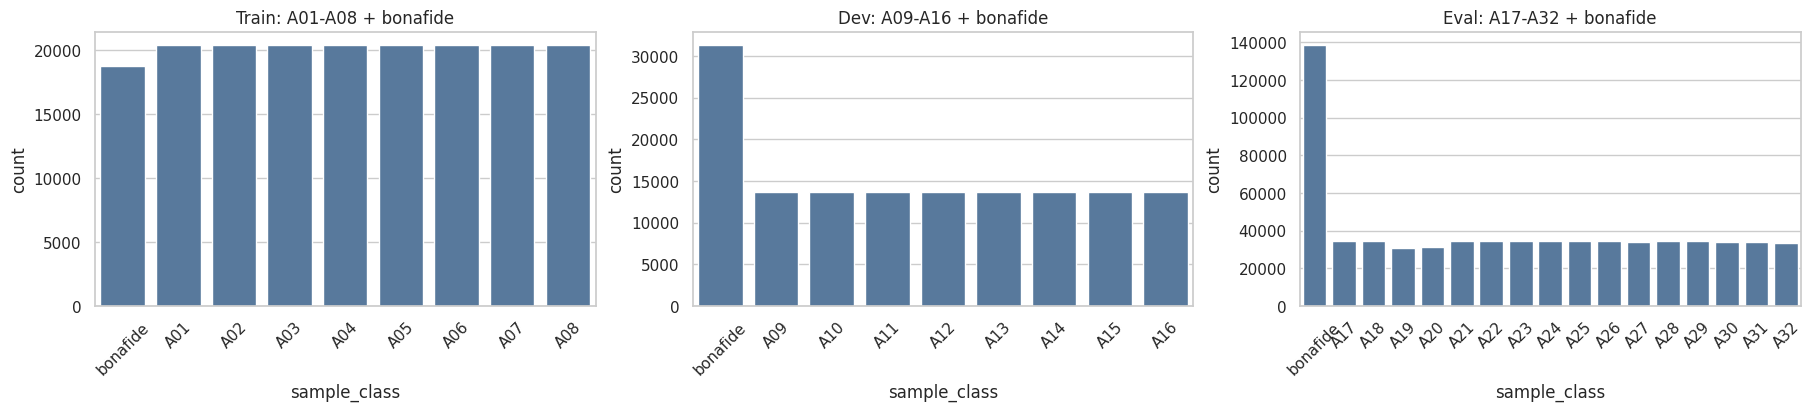

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
for ax, df_part, classes, title in [
    (axes[0], train_df, TRAIN_SYSTEMS, 'Train: A01-A08 + bonafide'),
    (axes[1], dev_df, DEV_SYSTEMS, 'Dev: A09-A16 + bonafide'),
    (axes[2], eval_df, EVAL_SYSTEMS, 'Eval: A17-A32 + bonafide'),
]:
    ordered = ['bonafide'] + classes
    counts = df_part['sample_class'].value_counts().reindex(ordered, fill_value=0)
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel('sample_class')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
plt.show()


## Experiment Framing: 16 Binary Tasks

This setup is **not** a single multiclass problem over `A01-A16`. The intended later modeling stage is `16` separate binary logistic-regression tasks:

- from `train`: `bonafide vs A01`, ..., `bonafide vs A08`
- from `dev`: `bonafide vs A09`, ..., `bonafide vs A16`

The table below defines those planned tasks explicitly.


In [11]:
task_table = pd.DataFrame(
    [{'partition': 'train', 'task': f'bonafide vs {sys_id}', 'system_id': sys_id} for sys_id in TRAIN_SYSTEMS] +
    [{'partition': 'dev', 'task': f'bonafide vs {sys_id}', 'system_id': sys_id} for sys_id in DEV_SYSTEMS]
)
display(task_table)


,partition,task,system_id
0,train,bonafide vs A01,A01
1,train,bonafide vs A02,A02
2,train,bonafide vs A03,A03
3,train,bonafide vs A04,A04
4,train,bonafide vs A05,A05
5,train,bonafide vs A06,A06
6,train,bonafide vs A07,A07
7,train,bonafide vs A08,A08
8,dev,bonafide vs A09,A09
9,dev,bonafide vs A10,A10


## Candidate Subset Planning Statistics

These tables show how much data each speaker contributes for bonafide and for the relevant spoof systems. The goal is to estimate realistic speaker budgets for the later `prepare_asvspoof5.ipynb` notebook.


In [12]:
def speaker_availability(df_part: pd.DataFrame, systems: list[str]) -> pd.DataFrame:
    rel = df_part[df_part['sample_class'].isin(['bonafide'] + systems)].copy()
    piv = rel.groupby(['speaker_id', 'sample_class']).size().unstack(fill_value=0)
    for col in ['bonafide'] + systems:
        if col not in piv.columns:
            piv[col] = 0
    piv = piv[['bonafide'] + systems]
    piv['total_selected_classes'] = piv[['bonafide'] + systems].sum(axis=1)
    piv['num_nonzero_systems'] = (piv[systems] > 0).sum(axis=1)
    gender = rel.groupby('speaker_id')['gender'].first().rename('gender')
    return piv.join(gender, how='left').reset_index()

train_availability = speaker_availability(train_df, TRAIN_SYSTEMS)
dev_availability = speaker_availability(dev_df, DEV_SYSTEMS)

display(Markdown('### Train speaker availability'))
display(train_availability.head(20))
display(Markdown('### Dev speaker availability'))
display(dev_availability.head(20))


### Train speaker availability

,speaker_id,bonafide,A01,A02,A03,A04,A05,A06,A07,A08,total_selected_classes,num_nonzero_systems,gender
0,T_0012,50,60,60,60,60,60,60,60,60,530,8,M
1,T_0020,9,30,30,30,30,30,30,30,30,249,8,M
2,T_0023,50,60,60,60,60,60,60,60,60,530,8,F
3,T_0027,50,60,60,60,60,60,60,60,60,530,8,F
4,T_0039,50,30,30,30,30,30,30,30,30,290,8,F
5,T_0046,50,60,60,60,60,60,60,60,60,530,8,F
6,T_0052,50,60,60,60,60,60,60,60,60,530,8,F
7,T_0091,50,30,30,30,30,30,30,30,30,290,8,F
8,T_0101,50,60,60,60,60,60,60,60,60,530,8,F
9,T_0141,50,60,60,60,60,60,60,60,60,530,8,F


### Dev speaker availability

,speaker_id,bonafide,A09,A10,A11,A12,A13,A14,A15,A16,total_selected_classes,num_nonzero_systems,gender
0,D_0003,48,0,0,0,0,0,0,0,0,48,0,F
1,D_0004,50,24,24,24,24,24,24,24,24,242,8,M
2,D_0006,22,0,0,0,0,0,0,0,0,22,0,F
3,D_0013,49,0,0,0,0,0,0,0,0,49,0,M
4,D_0028,49,0,0,0,0,0,0,0,0,49,0,M
5,D_0050,49,0,0,0,0,0,0,0,0,49,0,F
6,D_0059,50,47,47,47,47,47,47,47,47,426,8,F
7,D_0062,50,33,33,33,33,33,33,33,33,314,8,F
8,D_0065,9,13,13,13,13,13,13,13,13,113,8,M
9,D_0087,13,14,14,14,14,14,14,14,14,125,8,F


In [13]:
train_full_coverage = train_availability[(train_availability['bonafide'] > 0) & (train_availability[TRAIN_SYSTEMS] > 0).all(axis=1)].copy()
dev_full_coverage = dev_availability[(dev_availability['bonafide'] > 0) & (dev_availability[DEV_SYSTEMS] > 0).all(axis=1)].copy()

coverage_summary = pd.DataFrame([
    {
        'partition': 'train',
        'relevant_systems': ', '.join(TRAIN_SYSTEMS),
        'eligible_speakers_with_full_system_coverage': len(train_full_coverage),
        'total_speakers': train_availability['speaker_id'].nunique(),
    },
    {
        'partition': 'dev',
        'relevant_systems': ', '.join(DEV_SYSTEMS),
        'eligible_speakers_with_full_system_coverage': len(dev_full_coverage),
        'total_speakers': dev_availability['speaker_id'].nunique(),
    },
])
display(coverage_summary)


,partition,relevant_systems,eligible_speakers_with_full_system_coverage,total_speakers
0,train,"A01, A02, A03, A04, A05, A06, A07, A08",400,400
1,dev,"A09, A10, A11, A12, A13, A14, A15, A16",392,785


In [14]:
def planning_budget_table(availability: pd.DataFrame, systems: list[str], partition: str) -> pd.DataFrame:
    rows = []
    for spk_n in RECOMMENDED_SPEAKER_COUNTS:
        top = availability.sort_values('total_selected_classes', ascending=False).head(spk_n)
        if len(top) < spk_n:
            continue
        bon_min = int(top['bonafide'].min())
        system_mins = {sys_id: int(top[sys_id].min()) for sys_id in systems}
        max_even_per_system = min(system_mins.values()) if system_mins else 0
        rows.append({
            'partition': partition,
            'speaker_budget': spk_n,
            'min_bonafide_per_selected_speaker': bon_min,
            'min_per_system_per_selected_speaker': max_even_per_system,
            'balanced_binary_total_if_using_all_systems': spk_n * min(bon_min, len(systems) * max_even_per_system),
        })
    return pd.DataFrame(rows)

budget_table = pd.concat([
    planning_budget_table(train_availability, TRAIN_SYSTEMS, 'train'),
    planning_budget_table(dev_availability, DEV_SYSTEMS, 'dev'),
], ignore_index=True)
display(budget_table)


,partition,speaker_budget,min_bonafide_per_selected_speaker,min_per_system_per_selected_speaker,balanced_binary_total_if_using_all_systems
0,train,6,50,60,300
1,train,8,50,60,400
2,train,10,50,60,500
3,train,12,50,60,600
4,dev,6,50,53,300
5,dev,8,50,53,400
6,dev,10,50,53,500
7,dev,12,50,52,600


In [15]:
def recommended_note(availability: pd.DataFrame, systems: list[str], partition: str) -> str:
    if availability.empty:
        return f'- {partition}: no availability table could be computed.'
    top6 = availability.sort_values('total_selected_classes', ascending=False).head(6)
    bon_min = int(top6['bonafide'].min()) if len(top6) == 6 else 0
    sys_min = int(min(top6[systems].min())) if len(top6) == 6 else 0
    return (
        f'- {partition}: a conservative starting point is `6` speakers with at least '
        f'`{bon_min}` bonafide and `{sys_min}` samples per spoof system among the top-coverage speakers.'
    )

recommendation_lines = [
    '### Recommended starting budgets for `prepare_asvspoof5.ipynb`',
    recommended_note(train_availability, TRAIN_SYSTEMS, 'train'),
    recommended_note(dev_availability, DEV_SYSTEMS, 'dev'),
    '- keep the later preparation stage binary and balanced per task, rather than trying to make one large multiclass subset first.',
]
display(Markdown(''.join(recommendation_lines)))


### Recommended starting budgets for `prepare_asvspoof5.ipynb`- train: a conservative starting point is `6` speakers with at least `50` bonafide and `60` samples per spoof system among the top-coverage speakers.- dev: a conservative starting point is `6` speakers with at least `50` bonafide and `53` samples per spoof system among the top-coverage speakers.- keep the later preparation stage binary and balanced per task, rather than trying to make one large multiclass subset first.

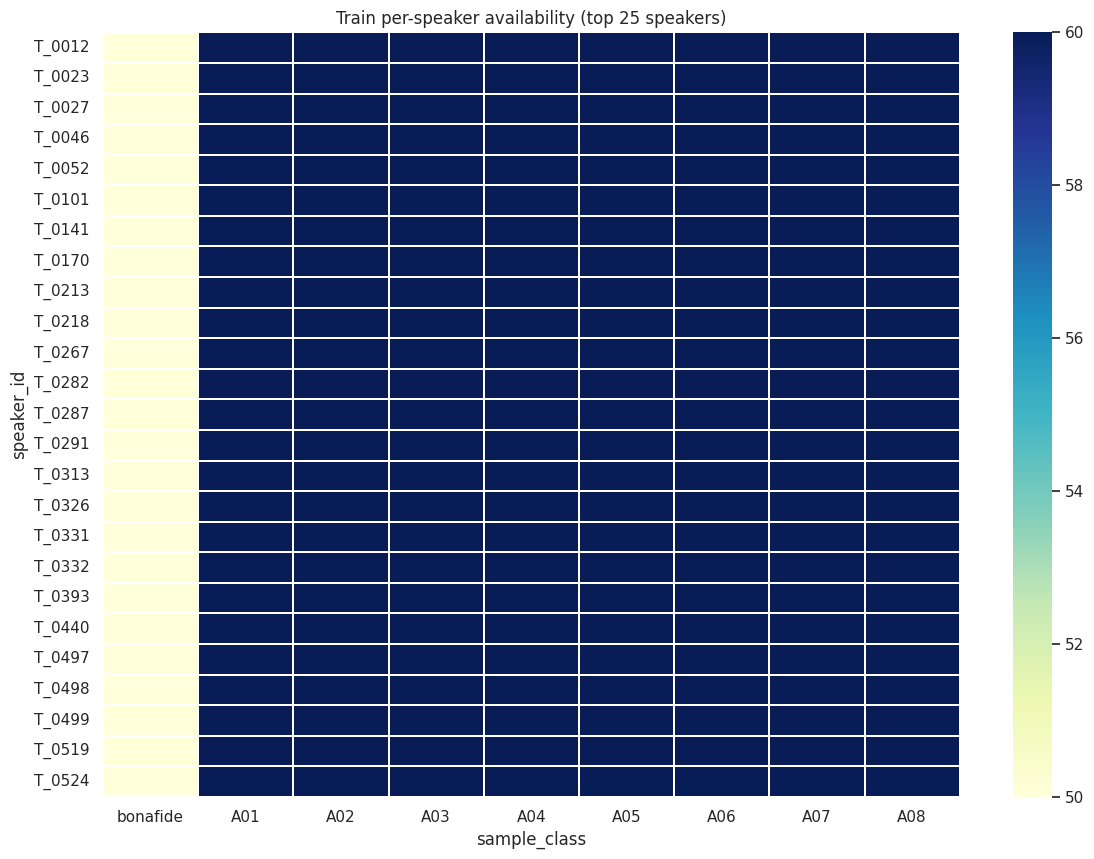

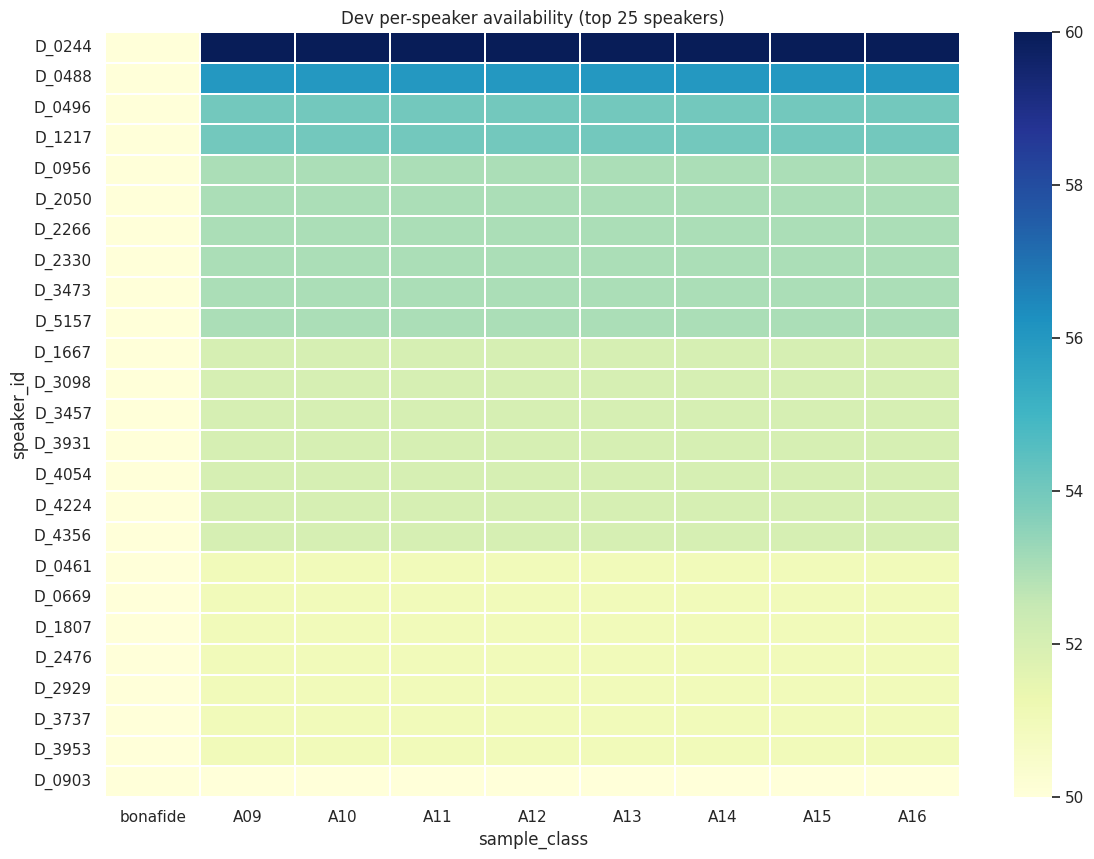

In [16]:
def plot_availability_heatmap(availability: pd.DataFrame, systems: list[str], title: str):
    heat = availability.set_index('speaker_id')[['bonafide'] + systems]
    heat = heat.sort_values(['bonafide'] + systems, ascending=False).head(25)
    plt.figure(figsize=(12, max(4, 0.35 * len(heat))))
    sns.heatmap(heat, cmap='YlGnBu', linewidths=0.2)
    plt.title(title)
    plt.xlabel('sample_class')
    plt.ylabel('speaker_id')
    plt.tight_layout()
    plt.show()

plot_availability_heatmap(train_availability, TRAIN_SYSTEMS, 'Train per-speaker availability (top 25 speakers)')
plot_availability_heatmap(dev_availability, DEV_SYSTEMS, 'Dev per-speaker availability (top 25 speakers)')


## Sentence / Source-Match Feasibility

The current protocol view is enough for speaker-level and system-level planning, but it does **not** expose a reliable source-utterance linkage for `train` and `dev`. That means the later preparation notebook can guarantee **same speaker** coverage, but not **same sentence across systems**, unless a richer upstream metadata file is found elsewhere.


In [17]:
placeholder_columns = ['c3', 'c4', 'c5', 'unused']
placeholder_report = all_df[placeholder_columns].nunique(dropna=False).rename('nunique').reset_index().rename(columns={'index': 'column'})
display(placeholder_report)

feasibility_lines = [
    '### Feasibility conclusion',
    '- The train/dev protocol files provide `speaker_id`, `utt_id`, `gender`, `codec_id`, `system_id`, and `label`.',
    '- They do not expose a clear `source_utt_id` field for train/dev that would let us prove same-sentence matching across systems.',
    '- Therefore, the later subset-preparation notebook should plan around same-speaker balancing, not same-sentence balancing.',
]
display(Markdown(''.join(feasibility_lines)))


,column,nunique
0,c3,12
1,c4,10
2,c5,171603
3,unused,1


### Feasibility conclusion- The train/dev protocol files provide `speaker_id`, `utt_id`, `gender`, `codec_id`, `system_id`, and `label`.- They do not expose a clear `source_utt_id` field for train/dev that would let us prove same-sentence matching across systems.- Therefore, the later subset-preparation notebook should plan around same-speaker balancing, not same-sentence balancing.

## Final Planning Summary

This final block collects the core answers needed before creating `prepare_asvspoof5.ipynb`.


In [18]:
final_summary = pd.DataFrame([
    {
        'question': 'How many speakers exist in train?',
        'answer': int(train_df['speaker_id'].nunique()),
    },
    {
        'question': 'How many speakers exist in dev?',
        'answer': int(dev_df['speaker_id'].nunique()),
    },
    {
        'question': 'How many speakers exist in eval?',
        'answer': int(eval_df['speaker_id'].nunique()),
    },
    {
        'question': 'Do train and dev share speakers?',
        'answer': 'No' if len(train_speakers & dev_speakers) == 0 else 'Yes',
    },
    {
        'question': 'Is same-sentence matching feasible from current train/dev protocol files?',
        'answer': 'No, not from these files alone',
    },
    {
        'question': 'Planned task type',
        'answer': '16 separate binary bonafide-vs-system logistic regressions',
    },
])
display(final_summary)


,question,answer
0,How many speakers exist in train?,400
1,How many speakers exist in dev?,785
2,How many speakers exist in eval?,737
3,Do train and dev share speakers?,No
4,Is same-sentence matching feasible from curren...,"No, not from these files alone"
5,Planned task type,16 separate binary bonafide-vs-system logistic...
